# LLM Fine-tuning with Evolutionary Strategies

Fine-tune RWKV7 0.1B using EggRoll / ESSA / OpenES evolutionary strategies.

**Requirements:** Colab with T4 GPU runtime.

In [1]:
# Verify GPU is available
!nvidia-smi

Wed Feb 18 18:28:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P0             43W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
if os.path.exists("/content/HyperscaleES"):
    !cd /content/HyperscaleES && git pull
else:
    !git clone -b warming-up https://github.com/shr1ram/HyperscaleES.git /content/HyperscaleES
%cd /content/HyperscaleES
!pip install -e . -q

Already up to date.
/content/HyperscaleES
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for hyperscalees (pyproject.toml) ... done


## Configuration

Change `NOISER` below to switch between evolutionary strategies. Everything else stays the same.

In [ ]:
# ============================================
#  CHANGE THIS TO SWITCH NOISER
# ============================================
NOISER = "essa"    # "eggroll", "essa", or "open_es"
# ============================================

# Training hyperparameters
MODEL_CHOICE = "7g0.1B"
TASK = "fastzero"
NUM_EPOCHS = 10
BATCH_SIZE = 1024       # reduce to 256 if OOM
SIGMA = 1e-3
LR_SCALE = 1.0

print(f"Noiser:  {NOISER}")
print(f"Model:   {MODEL_CHOICE}")
print(f"Task:    {TASK}")
print(f"Epochs:  {NUM_EPOCHS}")
print(f"Batch:   {BATCH_SIZE}")

Noiser:  eggroll
Model:   7g0.1B
Task:    fastzero
Epochs:  10
Batch:   1024


## Sanity check

Quick end-to-end test: trains a small MLP to predict the number 2.

In [4]:
!python tests/end_to_end_test.py

2026-02-18 18:29:03.822044: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771439343.854842    9307 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771439343.866089    9307 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771439343.890545    9307 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771439343.890585    9307 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771439343.890593    9307 computation_placer.cc:177] computation placer alr

## Fine-tune

In [5]:
!python -m llm_experiments.general_do_evolution \
    --model_choice $MODEL_CHOICE \
    --task $TASK \
    --num_epochs $NUM_EPOCHS \
    --parallel_generations_per_gpu $BATCH_SIZE \
    --sigma $SIGMA \
    --lr_scale $LR_SCALE \
    --noiser $NOISER 2>&1 | tee train.log

2026-02-18 18:29:22.683691: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771439362.707380    9414 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771439362.719713    9414 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771439362.739921    9414 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771439362.739942    9414 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771439362.739945    9414 computation_placer.cc:177] computation placer alr

## Training plots

In [6]:
import re
import matplotlib.pyplot as plt

with open("train.log") as f:
    log = f.read()

avg_fit, std_fit, max_fit, min_fit, median_fit = [], [], [], [], []
lora_upd, nonlora_upd = [], []
val_scores = []

for m in re.finditer(
    r"\tavg_fitness:\s*([-\d.e+]+).*?"
    r"\tstd_fitness:\s*([-\d.e+]+).*?"
    r"\tmax_fitness:\s*([-\d.e+]+).*?"
    r"\tmin_fitness:\s*([-\d.e+]+).*?"
    r"\tmedian_fitness:\s*([-\d.e+]+).*?"
    r"\tlora_updates:\s*([-\d.e+]+).*?"
    r"\tnonlora_updates:\s*([-\d.e+]+)",
    log, re.DOTALL,
):
    avg_fit.append(float(m.group(1)))
    std_fit.append(float(m.group(2)))
    max_fit.append(float(m.group(3)))
    min_fit.append(float(m.group(4)))
    median_fit.append(float(m.group(5)))
    lora_upd.append(float(m.group(6)))
    nonlora_upd.append(float(m.group(7)))

for m in re.finditer(r"VALIDATION SCORE=\s*([-\d.e+]+)", log):
    val_scores.append(float(m.group(1)))

epochs = list(range(len(avg_fit)))
val_epochs = [i * 10 for i in range(len(val_scores))]

print(f"Parsed {len(epochs)} training epochs, {len(val_scores)} validation points")

Parsed 10 training epochs, 1 validation points


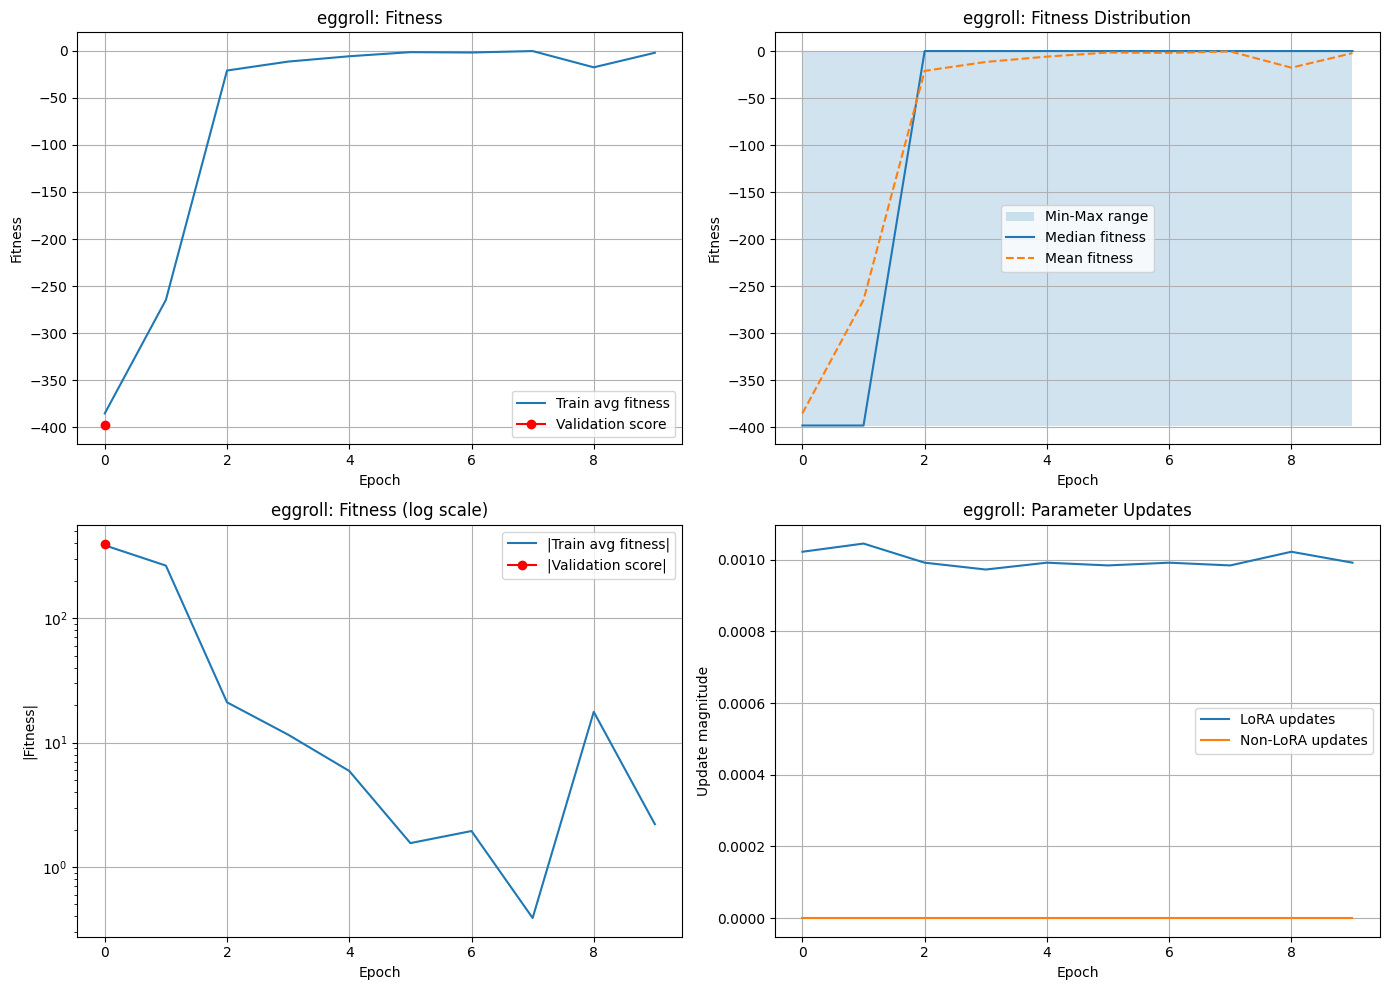

Saved to training_plots.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Fitness over training
ax = axes[0, 0]
ax.plot(epochs, avg_fit, label="Train avg fitness")
if val_scores:
    ax.plot(val_epochs, val_scores, "ro-", label="Validation score")
ax.set_xlabel("Epoch")
ax.set_ylabel("Fitness")
ax.set_title(f"{NOISER}: Fitness")
ax.legend()
ax.grid(True)

# 2. Fitness spread (min/max/median)
ax = axes[0, 1]
ax.fill_between(epochs, min_fit, max_fit, alpha=0.2, label="Min-Max range")
ax.plot(epochs, median_fit, label="Median fitness")
ax.plot(epochs, avg_fit, label="Mean fitness", linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Fitness")
ax.set_title(f"{NOISER}: Fitness Distribution")
ax.legend()
ax.grid(True)

# 3. Fitness (log scale)
ax = axes[1, 0]
ax.plot(epochs, [-x if x < 0 else x for x in avg_fit], label="|Train avg fitness|")
if val_scores:
    ax.plot(val_epochs, [-x if x < 0 else x for x in val_scores], "ro-", label="|Validation score|")
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("|Fitness|")
ax.set_title(f"{NOISER}: Fitness (log scale)")
ax.legend()
ax.grid(True)

# 4. LoRA vs non-LoRA update magnitudes
ax = axes[1, 1]
ax.plot(epochs, lora_upd, label="LoRA updates")
ax.plot(epochs, nonlora_upd, label="Non-LoRA updates")
ax.set_xlabel("Epoch")
ax.set_ylabel("Update magnitude")
ax.set_title(f"{NOISER}: Parameter Updates")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("training_plots.png", dpi=150)
plt.show()
print("Saved to training_plots.png")